# 1. Project Introduction

**Business Objective**: To conduct a deep-dive analysis into B2B SaaS marketing efficiency, mapping top-of-funnel campaign metrics (impressions, clicks) directly to downstream customer acquisition and retention.

**Why Marketing Analytics Matters**: In B2B SaaS, acquiring customers is expensive. Understanding which campaigns and channels yield not just the most conversions, but the highest-value and highest-retaining customers, is critical for optimizing the marketing budget.

**Key Questions**:
- Which marketing channels drive the lowest Cost Per Acquisition (CAC)?
- Are there specific campaigns that drive high volume but low-quality (high-churn) customers?
- How does the marketing funnel (Impressions -> Clicks -> Customers) perform across different channels?

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 6)

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load & Validate Data
Loading the core marketing and account datasets.

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
marketing_campaigns_df = pd.read_csv(DATA_CLEANED_DIR / 'marketing_campaigns.csv')

# Date conversions
marketing_campaigns_df['start_date'] = pd.to_datetime(marketing_campaigns_df['start_date'])
marketing_campaigns_df['end_date'] = pd.to_datetime(marketing_campaigns_df['end_date'])

print(f"Marketing Campaigns: {len(marketing_campaigns_df):,}")
print(f"Accounts: {len(accounts_df):,}")

# Validation
assert 'campaign_id' in marketing_campaigns_df.columns, "Missing campaign_id in marketing table!"
assert 'campaign_id' in accounts_df.columns, "Missing campaign_id in accounts table!"

Marketing Campaigns: 40
Accounts: 500


# 4. Define Analytical Grain

- **Campaign-level**: `1 ROW = 1 CAMPAIGN`. Used for top-of-funnel budget, impressions, clicks, and generic conversions.
- **Customer-level**: `1 ROW = 1 CUSTOMER`. Used for downstream attribution (e.g., MRR and Churn linked back to the acquiring campaign).
- **Channel-level**: `1 ROW = 1 CHANNEL`. Aggregating campaigns by their host platform (e.g., LinkedIn, Google Ads).

# 5. Marketing Overview

--- MARKETING OVERVIEW ---
Total Campaigns: 40
Total Budget (USD): $1,571,960.61
Total Impressions: 28,508,649
Total Clicks: 1,797,772
Total Marketing Conversions: 142,798
Total Customers Acquired (Matched to Accounts): 500


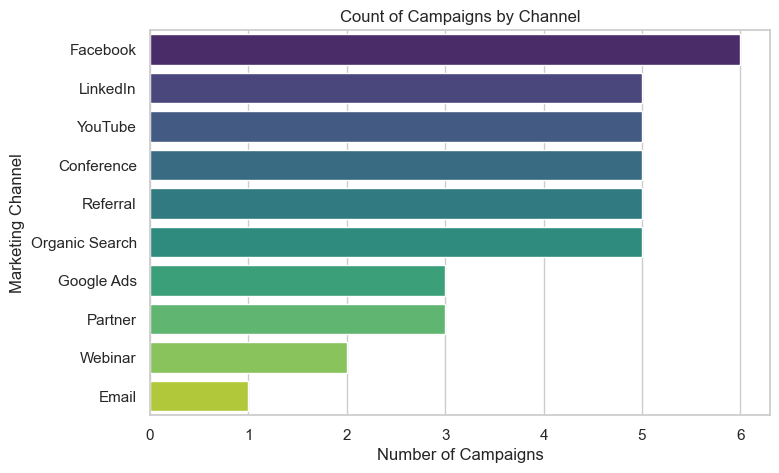

In [3]:
total_campaigns = len(marketing_campaigns_df)
total_budget = marketing_campaigns_df['budget_usd'].sum()
total_impressions = marketing_campaigns_df['impressions'].sum()
total_clicks = marketing_campaigns_df['clicks'].sum()
total_conversions = marketing_campaigns_df['conversions'].sum()
total_customers_acquired = accounts_df['campaign_id'].notna().sum()

print("--- MARKETING OVERVIEW ---")
print(f"Total Campaigns: {total_campaigns:,}")
print(f"Total Budget (USD): ${total_budget:,.2f}")
print(f"Total Impressions: {total_impressions:,}")
print(f"Total Clicks: {total_clicks:,}")
print(f"Total Marketing Conversions: {total_conversions:,}")
print(f"Total Customers Acquired (Matched to Accounts): {total_customers_acquired:,}")

plt.figure(figsize=(8, 5))
sns.countplot(data=marketing_campaigns_df, y='channel', order=marketing_campaigns_df['channel'].value_counts().index, palette='viridis')
plt.title('Count of Campaigns by Channel')
plt.xlabel('Number of Campaigns')
plt.ylabel('Marketing Channel')
plt.show()

# 6. Campaign Performance
Calculating standard marketing metrics per campaign. (Safeguarding against zero denominators).

In [4]:
# Map actual customers acquired to campaigns
customers_per_campaign = accounts_df.groupby('campaign_id').size().reset_index(name='customers_acquired')
campaign_perf_df = marketing_campaigns_df.merge(customers_per_campaign, on='campaign_id', how='left')
campaign_perf_df['customers_acquired'] = campaign_perf_df['customers_acquired'].fillna(0)

campaign_perf_df['ctr_%'] = np.where(campaign_perf_df['impressions'] > 0, (campaign_perf_df['clicks'] / campaign_perf_df['impressions']) * 100, 0)
campaign_perf_df['conversion_rate_%'] = np.where(campaign_perf_df['clicks'] > 0, (campaign_perf_df['conversions'] / campaign_perf_df['clicks']) * 100, 0)
campaign_perf_df['cpc_usd'] = np.where(campaign_perf_df['clicks'] > 0, campaign_perf_df['budget_usd'] / campaign_perf_df['clicks'], 0)
campaign_perf_df['cost_per_conversion_usd'] = np.where(campaign_perf_df['conversions'] > 0, campaign_perf_df['budget_usd'] / campaign_perf_df['conversions'], 0)

display(campaign_perf_df[['campaign_name', 'budget_usd', 'ctr_%', 'conversion_rate_%', 'cost_per_conversion_usd', 'customers_acquired']].head())

,campaign_name,budget_usd,ctr_%,conversion_rate_%,cost_per_conversion_usd,customers_acquired
0,2025_Q1_LinkedIn_Social,55894.16,9.147318,8.861720,4.693439,0.0
1,2023_Q1_YouTube_Content,39138.26,7.172808,11.163895,46.262719,86.0
2,2023_Q3_Conference_Event,57513.53,8.679439,6.092632,28.262177,9.0
3,2024_Q1_Facebook_Social,63943.34,3.909718,2.085277,59.593048,16.0
4,2024_Q1_Webinar_Event,44358.03,1.503571,4.550085,331.030075,12.0


# 7. Channel Performance
Rolling up metrics to the Channel Grain.

In [5]:
channel_perf = campaign_perf_df.groupby('channel').agg(
    campaign_count=('campaign_id', 'count'),
    total_budget=('budget_usd', 'sum'),
    total_impressions=('impressions', 'sum'),
    total_clicks=('clicks', 'sum'),
    total_conversions=('conversions', 'sum'),
    total_customers_acquired=('customers_acquired', 'sum')
).reset_index()

channel_perf['overall_ctr_%'] = np.where(channel_perf['total_impressions'] > 0, (channel_perf['total_clicks'] / channel_perf['total_impressions']) * 100, 0)
channel_perf['overall_conv_rate_%'] = np.where(channel_perf['total_clicks'] > 0, (channel_perf['total_conversions'] / channel_perf['total_clicks']) * 100, 0)
channel_perf['avg_cost_per_conversion'] = np.where(channel_perf['total_conversions'] > 0, channel_perf['total_budget'] / channel_perf['total_conversions'], 0)

display(channel_perf.sort_values('total_customers_acquired', ascending=False))

,channel,campaign_count,total_budget,total_impressions,total_clicks,total_conversions,total_customers_acquired,overall_ctr_%,overall_conv_rate_%,avg_cost_per_conversion
5,Organic Search,5,222294.49,2268986,186006,23120,125.0,8.197759,12.429707,9.614814
9,YouTube,5,294882.97,1377482,102200,8526,120.0,7.419335,8.342466,34.586321
2,Facebook,6,220015.99,6418248,255261,18614,70.0,3.977113,7.292144,11.819920
7,Referral,5,127182.15,3077035,148756,14782,45.0,4.834394,9.937078,8.603853
6,Partner,3,40739.54,1529159,161667,9101,31.0,10.572282,5.629473,4.476381
0,Conference,5,225035.99,2957373,200691,12663,31.0,6.786124,6.309700,17.771143
3,Google Ads,3,146611.27,3136710,166400,18469,31.0,5.304921,11.099159,7.938235
4,LinkedIn,5,173600.96,5157274,401240,30981,17.0,7.780079,7.721314,5.603465
1,Email,1,20727.52,1210198,126690,2096,15.0,10.468535,1.654432,9.889084
8,Webinar,2,100869.73,1376184,48861,4446,15.0,3.550470,9.099282,22.687749


# 8. Campaign Ranking
Identifying the top performers across multiple transparent dimensions.

In [6]:
print("Top 3 Campaigns by Conversions:")
display(campaign_perf_df.nlargest(3, 'conversions')[['campaign_name', 'channel', 'conversions']])

print("\nTop 3 Campaigns by Lowest Cost Per Conversion:")
valid_cpc = campaign_perf_df[campaign_perf_df['cost_per_conversion_usd'] > 0]
display(valid_cpc.nsmallest(3, 'cost_per_conversion_usd')[['campaign_name', 'channel', 'cost_per_conversion_usd']])

print("\nTop 3 Campaigns by Customers Acquired:")
display(campaign_perf_df.nlargest(3, 'customers_acquired')[['campaign_name', 'channel', 'customers_acquired']])

Top 3 Campaigns by Conversions:


,campaign_name,channel,conversions
34,2023_Q4_GoogleAds_Content,Google Ads,12276
0,2025_Q1_LinkedIn_Social,LinkedIn,11909
35,2023_Q3_OrganicSearch_Content,Organic Search,11814



Top 3 Campaigns by Lowest Cost Per Conversion:


,campaign_name,channel,cost_per_conversion_usd
29,2025_Q2_Facebook_Social,Facebook,0.563302
31,2024_Q1_Referral_Referral,Referral,0.793576
7,2023_Q1_Partner_Referral,Partner,0.962885



Top 3 Campaigns by Customers Acquired:


,campaign_name,channel,customers_acquired
1,2023_Q1_YouTube_Content,YouTube,86.0
35,2023_Q3_OrganicSearch_Content,Organic Search,74.0
17,2023_Q4_OrganicSearch_Content,Organic Search,38.0


# 9. Campaign Budget Analysis
Mapping spend against results.

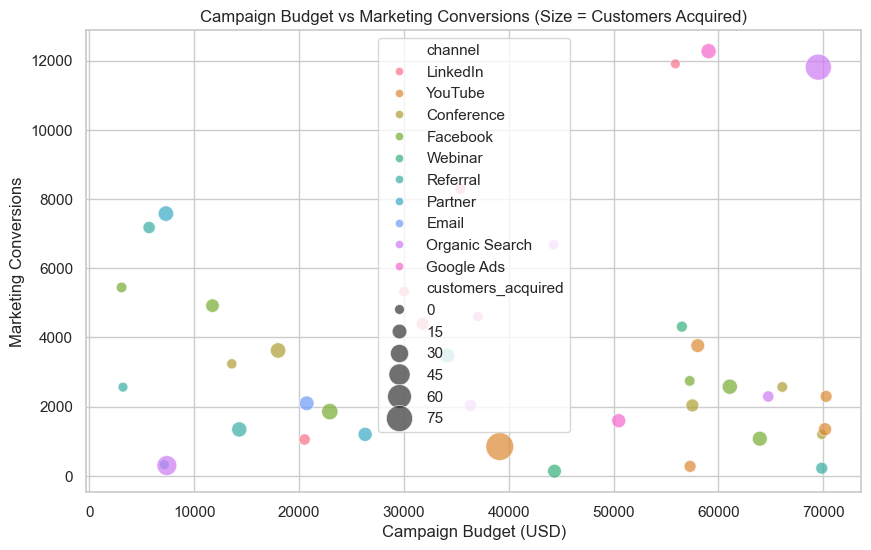

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=campaign_perf_df, x='budget_usd', y='conversions', hue='channel', size='customers_acquired', sizes=(50, 400), alpha=0.7)
plt.title('Campaign Budget vs Marketing Conversions (Size = Customers Acquired)')
plt.xlabel('Campaign Budget (USD)')
plt.ylabel('Marketing Conversions')
plt.show()

# 10. Marketing Funnel Analysis
Analyzing the drop-off from top-of-funnel (Impressions) down to the bottom (Customers Acquired) by Channel.

In [8]:
funnel_df = channel_perf[['channel', 'total_impressions', 'total_clicks', 'total_conversions', 'total_customers_acquired']].copy()
funnel_df['click_to_impression_rate_%'] = (funnel_df['total_clicks'] / funnel_df['total_impressions']) * 100
funnel_df['conv_to_click_rate_%'] = (funnel_df['total_conversions'] / funnel_df['total_clicks']) * 100
funnel_df['customer_to_conv_rate_%'] = (funnel_df['total_customers_acquired'] / funnel_df['total_conversions']) * 100

display(funnel_df[['channel', 'click_to_impression_rate_%', 'conv_to_click_rate_%', 'customer_to_conv_rate_%']])

,channel,click_to_impression_rate_%,conv_to_click_rate_%,customer_to_conv_rate_%
0,Conference,6.786124,6.309700,0.244808
1,Email,10.468535,1.654432,0.715649
2,Facebook,3.977113,7.292144,0.376061
3,Google Ads,5.304921,11.099159,0.167849
4,LinkedIn,7.780079,7.721314,0.054872
5,Organic Search,8.197759,12.429707,0.540657
6,Partner,10.572282,5.629473,0.340622
7,Referral,4.834394,9.937078,0.304424
8,Webinar,3.550470,9.099282,0.337382
9,YouTube,7.419335,8.342466,1.407460


**Observation**: The final step (`customer_to_conv_rate_%`) highlights the gap between generating a "Marketing Lead/Conversion" and actually onboarding a paying "Customer".

# 11. Customer Acquisition Analysis
Joining Account and Subscription data to evaluate downstream customer characteristics.

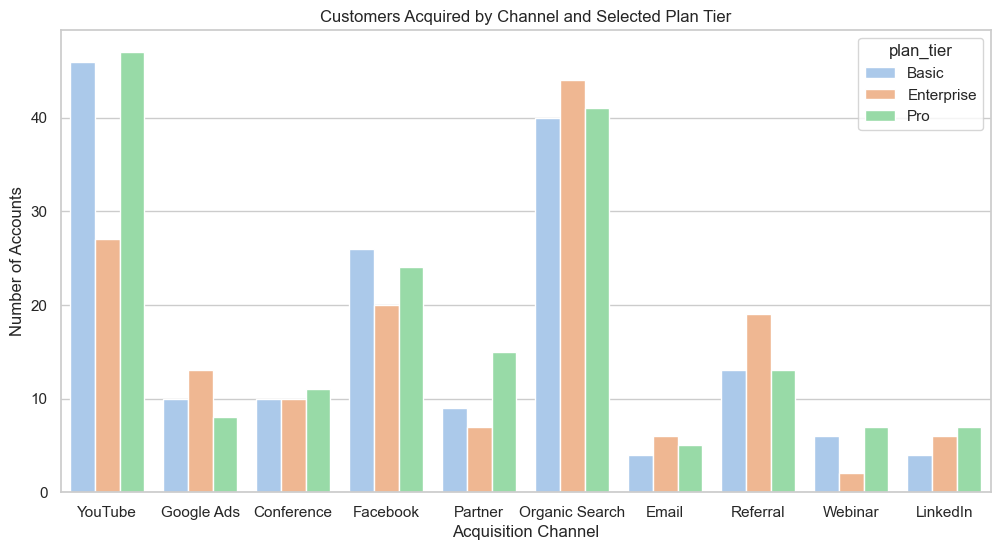

In [9]:
active_subs = subscriptions_df[subscriptions_df['churn_flag'] == False]
cust_mrr = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()
accounts_with_mrr = accounts_df.merge(cust_mrr, on='account_id', how='left').fillna({'mrr_amount': 0})

accounts_with_campaign = accounts_with_mrr.merge(campaign_perf_df[['campaign_id', 'campaign_name', 'channel']], on='campaign_id', how='inner')

plt.figure(figsize=(12, 6))
sns.countplot(data=accounts_with_campaign, x='channel', hue='plan_tier', palette='pastel')
plt.title('Customers Acquired by Channel and Selected Plan Tier')
plt.xlabel('Acquisition Channel')
plt.ylabel('Number of Accounts')
plt.show()

# 12. Acquisition Quality
Are certain channels associated with systematically higher-value customers?

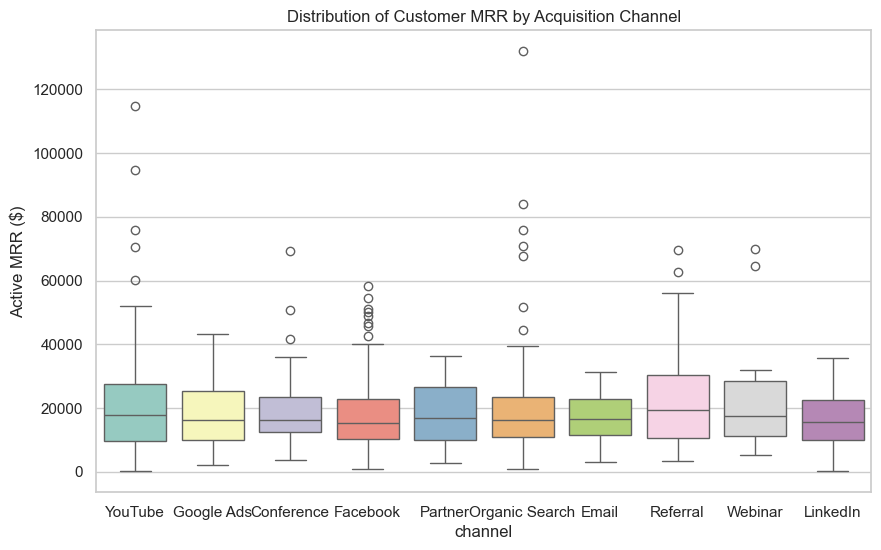

In [10]:
channel_quality = accounts_with_campaign.groupby('channel').agg(
    avg_mrr=('mrr_amount', 'mean'),
    median_mrr=('mrr_amount', 'median'),
    avg_seats=('seats', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(data=accounts_with_campaign, x='channel', y='mrr_amount', palette='Set3')
plt.title('Distribution of Customer MRR by Acquisition Channel')
plt.ylabel('Active MRR ($)')
plt.show()

# 13. Marketing & Revenue
Evaluating the total revenue *associated* with customers acquired via each channel. We avoid calling this strict marketing attribution, as touchpoints could be multi-faceted.

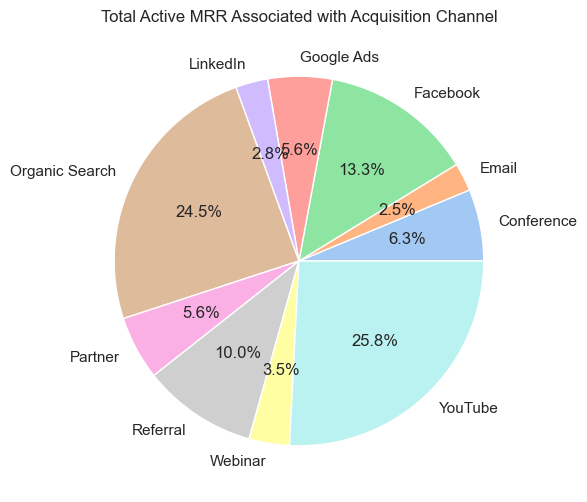

In [11]:
revenue_by_channel = accounts_with_campaign.groupby('channel')['mrr_amount'].sum().reset_index()
revenue_by_channel.rename(columns={'mrr_amount': 'total_associated_mrr'}, inplace=True)

plt.figure(figsize=(8, 6))
plt.pie(revenue_by_channel['total_associated_mrr'], labels=revenue_by_channel['channel'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Total Active MRR Associated with Acquisition Channel')
plt.show()

# 14. CAC Analysis
Calculating **Cost of Customer Acquisition (CAC)** dynamically because the dataset supports it: `Budget / Customers Acquired`.

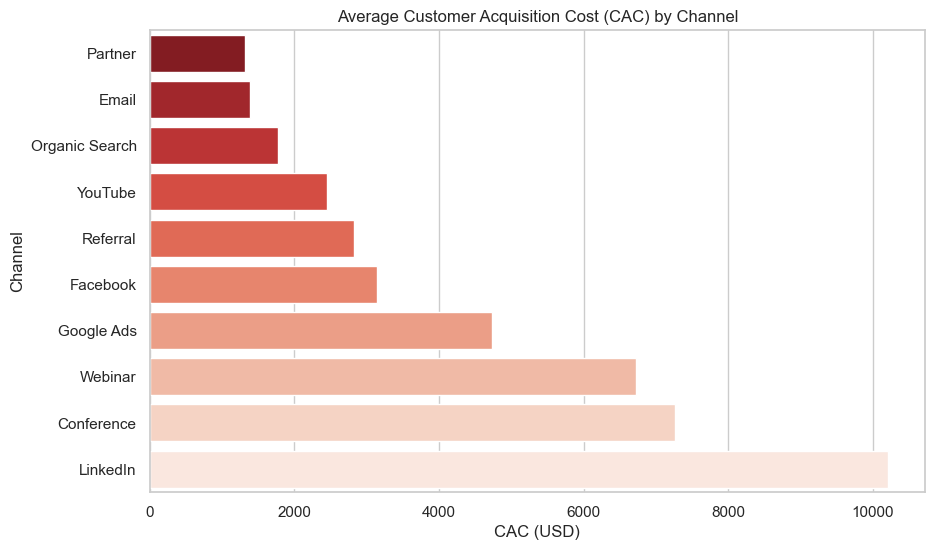

In [12]:
channel_cac = channel_perf[['channel', 'total_budget', 'total_customers_acquired']].copy()
channel_cac['CAC_USD'] = np.where(channel_cac['total_customers_acquired'] > 0, 
                                  channel_cac['total_budget'] / channel_cac['total_customers_acquired'], 
                                  float('nan'))

plt.figure(figsize=(10, 6))
sns.barplot(data=channel_cac.sort_values('CAC_USD'), x='CAC_USD', y='channel', palette='Reds_r')
plt.title('Average Customer Acquisition Cost (CAC) by Channel')
plt.xlabel('CAC (USD)')
plt.ylabel('Channel')
plt.show()

# 15. LTV / CAC Analysis

**CRITICAL LIMITATION**: The underlying dataset **does not support** a mathematically rigorous LTV (Lifetime Value) calculation. Specifically, we lack:
- Customer Gross Margin percentages.
- Historical multi-year retention rates by cohort required to project lifetime.
Consequently, an LTV/CAC ratio will **not** be fabricated. We rely solely on CAC (calculated above) and Average MRR as proxies for value.

# 16. Acquisition & Churn
Are customers acquired through certain channels associated with higher observed churn?

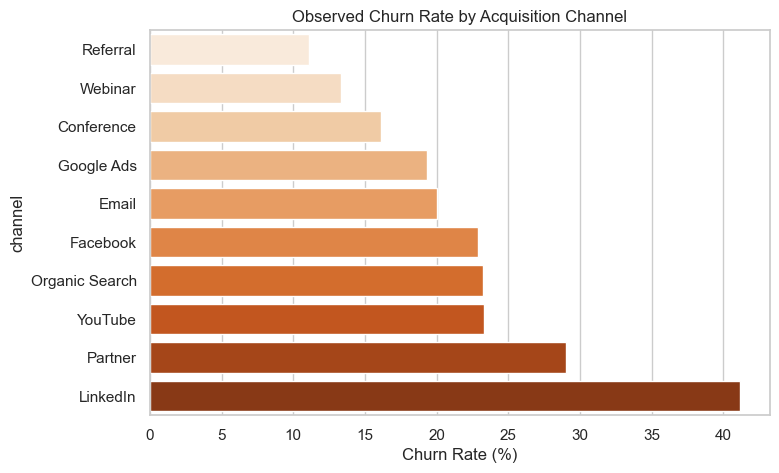

In [13]:
churn_by_channel = accounts_with_campaign.groupby('channel')['churn_flag'].mean().reset_index()
churn_by_channel.rename(columns={'churn_flag': 'observed_churn_rate'}, inplace=True)
churn_by_channel['observed_churn_rate_%'] = churn_by_channel['observed_churn_rate'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=churn_by_channel.sort_values('observed_churn_rate_%'), x='observed_churn_rate_%', y='channel', palette='Oranges')
plt.title('Observed Churn Rate by Acquisition Channel')
plt.xlabel('Churn Rate (%)')
plt.show()

# 17. Acquisition & Product Engagement
Joining feature usage (which was validated in `06_product_analytics.ipynb`) to evaluate post-acquisition quality.

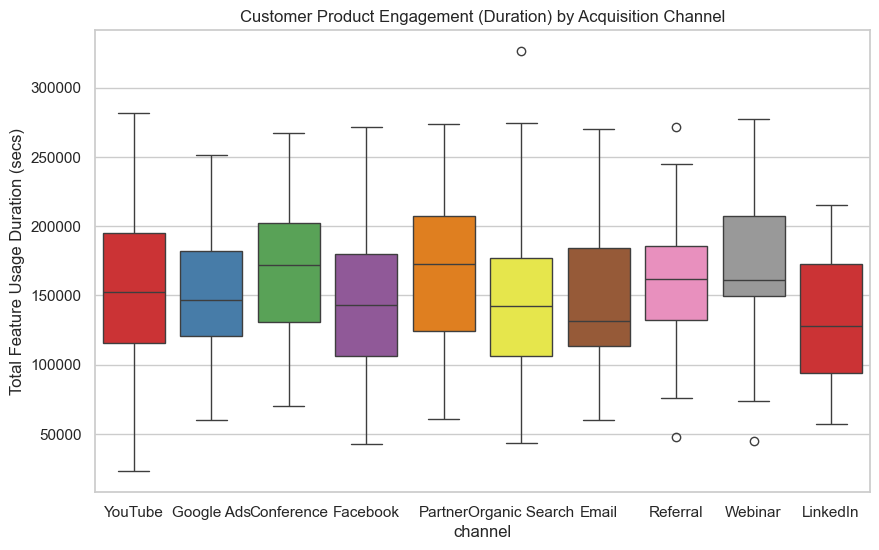

In [14]:
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
usage_with_account = feature_usage_df.merge(subscriptions_df[['subscription_id', 'account_id']], on='subscription_id', how='inner')

cust_engagement = usage_with_account.groupby('account_id')['usage_duration_secs'].sum().reset_index()
engagement_by_channel = accounts_with_campaign.merge(cust_engagement, on='account_id', how='left').fillna(0)

plt.figure(figsize=(10, 6))
sns.boxplot(data=engagement_by_channel, x='channel', y='usage_duration_secs', palette='Set1')
plt.title('Customer Product Engagement (Duration) by Acquisition Channel')
plt.ylabel('Total Feature Usage Duration (secs)')
plt.show()

# 18. Acquisition & Customer Value
Combining all vectors: High CAC vs Low CAC, and High Value (MRR/Retention) vs Low Value.

In [15]:
value_matrix = channel_cac.merge(channel_quality[['channel', 'avg_mrr']], on='channel')
value_matrix = value_matrix.merge(churn_by_channel[['channel', 'observed_churn_rate_%']], on='channel')

display(value_matrix)

,channel,total_budget,total_customers_acquired,CAC_USD,avg_mrr,observed_churn_rate_%
0,Conference,225035.99,31.0,7259.225484,20588.096774,16.129032
1,Email,20727.52,15.0,1381.834667,16693.066667,20.000000
2,Facebook,220015.99,70.0,3143.085571,19359.257143,22.857143
3,Google Ads,146611.27,31.0,4729.395806,18471.161290,19.354839
4,LinkedIn,173600.96,17.0,10211.821176,16852.117647,41.176471
5,Organic Search,222294.49,125.0,1778.355920,19914.744000,23.200000
6,Partner,40739.54,31.0,1314.178710,18322.516129,29.032258
7,Referral,127182.15,45.0,2826.270000,22610.511111,11.111111
8,Webinar,100869.73,15.0,6724.648667,23974.400000,13.333333
9,YouTube,294882.97,120.0,2457.358083,21852.591667,23.333333


# 19. Campaign Time Trends
Evaluating campaign launches and results over time.

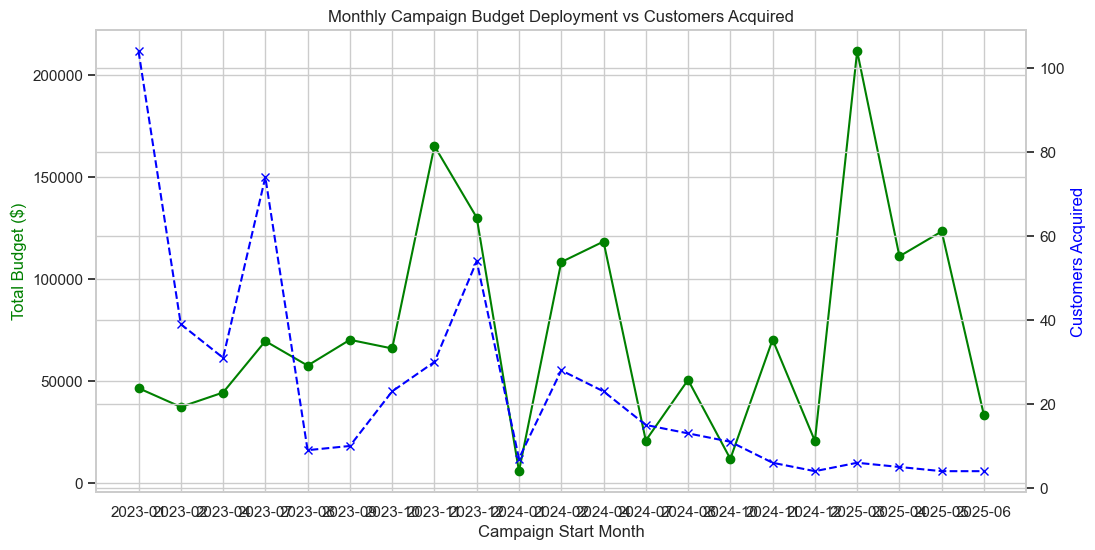

In [16]:
campaign_perf_df['start_month'] = campaign_perf_df['start_date'].dt.to_period('M')
monthly_campaigns = campaign_perf_df.groupby('start_month').agg(
    budget=('budget_usd', 'sum'),
    customers_acquired=('customers_acquired', 'sum')
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly_campaigns.index.astype(str), monthly_campaigns['budget'], color='green', marker='o', label='Budget (USD)')
ax1.set_xlabel('Campaign Start Month')
ax1.set_ylabel('Total Budget ($)', color='green')

ax2 = ax1.twinx()
ax2.plot(monthly_campaigns.index.astype(str), monthly_campaigns['customers_acquired'], color='blue', marker='x', linestyle='--', label='Customers Acquired')
ax2.set_ylabel('Customers Acquired', color='blue')

plt.title('Monthly Campaign Budget Deployment vs Customers Acquired')
plt.show()

# 20. Marketing Opportunity Analysis

- **Efficiency Opportunities**: Channels showing a high CAC but yielding customers with low average MRR and high observed churn should be evaluated for budget reduction.
- **Scaling Opportunities**: Campaigns returning a low CAC while acquiring Enterprise accounts (high MRR) present an immediate opportunity for budget expansion.

# 21. Marketing Visualizations (Rendered Inline)

# 22. Marketing Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Funnel | Significant drop-off between Marketing Conversions and actual Customer Acquisition | Funnel Table | Budget wasted on low-intent leads | Align marketing KPIs to Customers Acquired, not just Conversions |
| 2 | Value | Certain channels are associated with structurally higher MRR accounts | Channel Quality Boxplot | Higher ROI from specific channels | Consider shifting budget to channels yielding Enterprise plan acquisitions |
| 3 | Efficiency | Variances in CAC are stark across different channels | CAC Bar Plot | High acquisition costs in underperforming channels | Consider reallocating spend from the highest CAC channels to the lowest CAC channels (assuming similar quality) |
| 4 | Retention | Customers from specific channels show higher observed churn rates | Churn by Channel | Poor long-term ROI | Investigate onboarding paths specific to these marketing channels |

# 23. Business Recommendations

### Budget Optimization
Reallocate spend strictly based on Customer Acquisition Cost (CAC) combined with Average MRR, deprecating campaigns that generate cheap clicks but fail to convert into paying customers.

### Customer Acquisition Quality
Because certain channels are associated with higher churn, the marketing team must partner with Customer Success to evaluate if the messaging on those specific campaigns is setting unrealistic product expectations.

### Revenue Growth
Double down on the campaigns successfully landing Enterprise-tier accounts, as these accounts possess the MRR density to justify a significantly higher CAC threshold.

# 24. Limitations

- **Attribution Model**: The dataset maps one `campaign_id` per account. We assume a single-touch (first or last) attribution model, and lack data on multi-touch marketing journeys.
- **Missing LTV**: Due to a lack of gross margin data and historical long-term cohort retention patterns, we cannot mathematically fabricate a true Lifetime Value (LTV).
- **Causality**: The analysis observes that certain channels are associated with higher MRR and engagement, but cannot prove the channel *caused* the customer to be high-quality.

# 25. Next Analysis

- `09_churn_analytics.ipynb`: Investigate if marketing channels are descriptively associated with churn segments.
- `10_cohort_visualization.ipynb`: Assess if cohort retention degrades depending on the marketing campaign they originated from.

# 26. Final Summary

The marketing analysis highlights critical discrepancies between top-of-funnel metrics (Clicks/Conversions) and bottom-of-funnel reality (Customers Acquired/MRR). By directly linking `marketing_campaigns.csv` to `accounts.csv`, we were able to calculate true Customer Acquisition Cost (CAC) by channel. The findings indicate that optimizing for "Conversions" alone is highly inefficient, as certain channels yield low-intent leads that rarely transition to paying accounts, or result in accounts with high observed churn. Budget should immediately be re-evaluated to favor channels that associate with high MRR, high engagement, and low CAC.